<a href="https://colab.research.google.com/github/sborah53/Machine-Learning-for-Physical-Sciences/blob/main/MLPS_FLax_and_Optiax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics-Informed Machine Learning: The Flax & Optax Ecosystem
**The notebook was created by Sangkha Borah (IIT Hyderabad), Jan - Apr, 2026**


### Overview: The Paradigm Shift
In our previous exercises, we built a Feedforward Neural Network (FFNN) entirely from scratch using NumPy. That architecture relied heavily on **Object-Oriented Programming (OOP)**. The `FFNNPhysics` class encapsulated both the *architecture* (the layers) and the mutable *state* (the weight matrices $\boldsymbol{W}$ and bias vectors $\boldsymbol{b}$). During backpropagation, we iteratively executed in-place mutations like `self.W -= lr * dW`.

**Why does this fail in JAX?**
The XLA compiler (`jax.jit`) strictly requires **pure functions**. It cannot safely trace, compile, or differentiate through arbitrary Python state mutations. If a class method changes a variable in memory without returning it explicitly, it produces a side effect.

### Enter Flax and Optax
To solve this, the Google DeepMind ecosystem splits the problem into three pure, functional domains:
1. **Flax (`flax.linen`)**: Defines the *Ansatz* (the mathematical blueprint of the network). It separates the structural definition from the physical memory. The weights are stored externally in an immutable `PyTree`.
2. **Optax**: Treats optimization (Gradient Descent, Adam, Gradient Clipping) as a sequence of purely functional transformations applied to gradient vectors.
3. **JAX Core (`jit`, `grad`)**: Analytically differentiates the physics system and compiles the forward/backward pass into a single fused GPU binary.

In this notebook, we will reconstruct our Quantum Wavefunction approximation task from the ground up, entirely within this new ecosystem.



## Part I: The Physical System and Data Generation

Our objective is to discover a continuous, differentiable functional representation $\Psi_\theta(x)$ of a 1D quantum probability amplitude that has been obscured by experimental sensor noise.

The true target system is: $\Psi_{true}(x) = \sin(3x) \exp(-0.2x^2)$
The observed system is: $y_{measured} = \Psi_{true}(x) + \epsilon, \quad \epsilon \sim \mathscr{N}(0, \sigma^2)$

We will use purely `jax.numpy` and explicit `jax.random.PRNGKey` management to generate this dataset.

Generated 400 physical samples successfully.


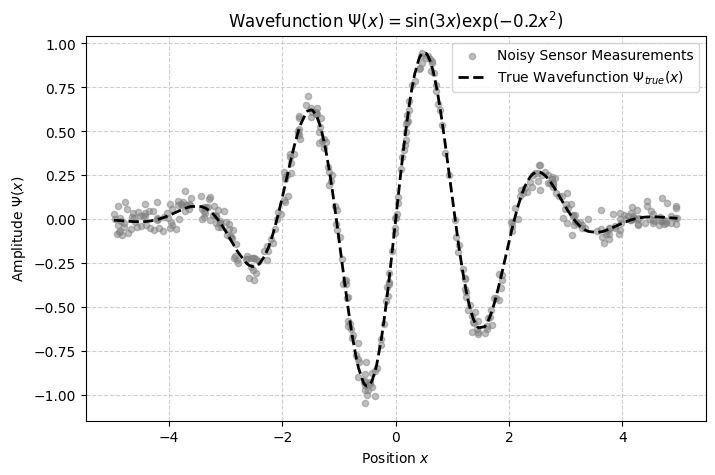

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Enforce 64-bit precision for strict physical accuracy
jax.config.update("jax_enable_x64", True)

def generate_wavefunction_data(key, n_samples=400):
    """
    Simulates the probability amplitude of a quantum harmonic oscillator state.
    """
    # 1. Strict PRNG Key Splitting
    k1, k2 = jax.random.split(key)

    # 2. Generate Spatial Coordinates uniformly across [-5, 5]
    X_raw = jnp.sort(jax.random.uniform(k1, (n_samples,), minval=-5, maxval=5))

    # 3. Standardization (Crucial for Neural Network stability)
    # Centering around 0 with a standard deviation of 1 prevents exploding gradients.
    X_mean = jnp.mean(X_raw)
    X_std = jnp.std(X_raw)
    X = (X_raw - X_mean) / X_std

    # 4. Define the true underlying physical law
    Y_true = jnp.sin(3 * X_raw) * jnp.exp(-0.2 * X_raw**2)

    # 5. Add experimental measurement noise
    Y_noisy = Y_true + jax.random.normal(k2, (n_samples,)) * 0.05

    # Reshape for Network (Features x Batch) -> Shape: (n_samples, 1)
    return X.reshape(-1, 1), Y_noisy.reshape(-1, 1), Y_true.reshape(-1, 1), X_raw.reshape(-1, 1)

root_key = jax.random.PRNGKey(42)
X_train, Y_train_noisy, Y_true, X_raw = generate_wavefunction_data(root_key)
print(f"Generated {X_train.shape[0]} physical samples successfully.")


fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# Plot 1: The Function Approximation
# We plot against X_raw (the true physical coordinate), not the standardized X
axes.scatter(X_raw, Y_train_noisy, color='gray', alpha=0.5, s=20,
                label='Noisy Sensor Measurements')
axes.plot(X_raw, Y_true, 'k--', lw=2, label=r'True Wavefunction $\Psi_{true}(x)$')
axes.set_title(r"Wavefunction $\Psi(x) = \sin(3x) \exp(-0.2x^2)$")
axes.set_xlabel(r"Position $x$")
axes.set_ylabel(r"Amplitude $\Psi(x)$")
axes.legend()
axes.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Part II: Defining the Variational Ansatz with Flax

Instead of manually defining `W` and `b` matrices, we use `flax.linen`.

A Flax `nn.Module` acts as a mathematical blueprint. The `@nn.compact` decorator allows us to define our feedforward kinematics sequentially. During initialization, Flax will perform a "dummy pass" with shape-only tracers to automatically infer the necessary dimensions for our parameter matrices, removing the need for manual $N_{in} \times N_{out}$ size declarations.

In [2]:
import flax.linen as nn

class QuantumAnsatz(nn.Module):
    """
    A Flax Module defining a feedforward neural network ansatz.
    We pass the layer dimensions dynamically as a sequence.
    """
    layer_dims: list  # Sequence of hidden/output nodes, e.g., [64, 1]

    @nn.compact
    def __call__(self, x):
        # 1. Hidden Layers: Symmetry Breaking via ReLU
        for dim in self.layer_dims[:-1]:
            # nn.Dense inherently handles Wx + b initialization (He/Lecun Normal)
            x = nn.Dense(features=dim)(x)
            x = nn.relu(x)

        # 2. Output Layer: Linear Activation for continuous physical regression
        # Maps the high-dimensional latent space back to a 1D scalar (Amplitude)
        x = nn.Dense(features=self.layer_dims[-1])(x)
        return x

# Instantiate the blueprint (Architecture: Input -> 64 Hidden -> 1 Output)
ansatz = QuantumAnsatz(layer_dims=[64, 1])

# Initialize the Physical Memory State (The PyTree)
# We must provide a PRNG key and a dummy input array to infer shapes.
init_key = jax.random.PRNGKey(42)
variables = ansatz.init(init_key, jnp.ones((1, 1))) # 1 batch, 1 feature

# Extract the actual weights (theta)
params = variables['params']

for i, (layer_name, layer_params) in enumerate(sorted(params.items())):
    print(f"Layer {i} ({layer_name}) W shape:", layer_params['kernel'].shape)


Layer 0 (Dense_0) W shape: (1, 64)
Layer 1 (Dense_1) W shape: (64, 1)


## Part III: The Thermodynamic Bath (Optax)

In our scratch implementation, we manually applied Global Gradient Norm Clipping to prevent exploding gradients, followed by Stochastic Gradient Descent ($W = W - \alpha dW$).

**Optax** manages this by chaining together *pure functional transformations*. An optimizer is initialized with our `params` PyTree, allocating a parallel PyTree to hold the optimizer's state (e.g., momentum vectors, iteration counts).

In [3]:
import optax

# 1. Define the optimization sequence (The Bath)
# optax.chain composes multiple gradient transformations sequentially.
learning_rate = 0.01
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), # Prevent gradient explosions
    optax.adamw(learning_rate)        # sgd, adam, adamw
)

# Note: If we wanted Adam, we would simply replace `optax.sgd` with `optax.adam`.
# The functional architecture remains completely unchanged!

## Part IV: The TrainState Abstraction

Managing the `apply` function, the `params` PyTree, and the `opt_state` PyTree separately becomes cumbersome when passing them in and out of compiled XLA graphs.

`flax.training.train_state` provides a `TrainState` object. This is a unified dataclass that binds the entire state of our physical simulation into a single immutable JAX PyTree. As the simulation steps forward in time, we simply generate a *new* `TrainState` object.

In [4]:
from flax.training import train_state

# Bind the model's apply function, the initialized parameters,
# and the optax optimizer into a single differentiable manifold.
state = train_state.TrainState.create(
    apply_fn=ansatz.apply,
    params=params,
    tx=optimizer
)

print("Unified TrainState created.")

Unified TrainState created.


## Part V: The Hamiltonian & JIT-Compiled Backpropagation

We now define the **Energy** of our system (the Loss function) and the compiled update step.

Instead of explicitly hardcoding recursive Jacobian chains ($\delta_l = \boldsymbol{W}_{l+1}^T \delta_{l+1} \odot g'(Z_l)$) as in the NumPy implementation, we utilize `jax.value_and_grad`. This instructs the XLA compiler to automatically trace the forward `apply_fn` operations, symbolically reverse them via the chain rule at compile-time, and fuse the entire forward and backward execution into a single blazing-fast GPU kernel.

In [5]:
@jax.jit
def train_step(state, X_batch, Y_batch):
    """
    Executes one step of compiled gradient descent.
    Takes the old state and returns the updated state.
    """

    # 1. Define the Loss Function (Hamiltonian)
    def compute_loss(params):
        # Forward kinematics: evaluating the ansatz
        Y_pred = state.apply_fn({'params': params}, X_batch)

        # Mean Squared Error (Elastic Potential Energy)
        # Using 1/(2m) to match the analytic derivative convention
        loss = jnp.mean(0.5 * (Y_pred - Y_batch)**2)
        return loss

    # 2. Exact Analytical Backpropagation
    # value_and_grad differentiates 'compute_loss' specifically with respect to 'params'
    loss, grads = jax.value_and_grad(compute_loss)(state.params)

    # 3. Update the System
    # apply_gradients automatically pushes 'grads' through the Optax chain
    # (executing the norm clip and the SGD step) to produce a new immutable state.
    new_state = state.apply_gradients(grads=grads)

    return new_state, loss

## Part VI: Orchestration and Execution

Finally, we execute the macroscopic training loop. Note that the Python `for` loop overhead is negligible because the mathematically intense workload (forward pass, loss, backprop, and parameter updates) is entirely sealed within the C++/GPU boundary behind the `@jax.jit` decorated `train_step`.

In [6]:
import time

epochs = 20000
loss_history = []
epochs_sampled = []

print("Beginning Variational Energy Minimization (Flax/Optax)...")
start_time = time.time()

for i in range(epochs):
    # The entire physics step is executed on the accelerator here
    state, cost = train_step(state, X_train, Y_train_noisy)

    if i % 1000 == 0:
        # We copy the cost back to the host CPU via float() for logging
        loss_history.append(float(cost))
        epochs_sampled.append(i)
        print(f"Epoch {i:5d} | System Energy (MSE Loss): {cost:.6f}")

end_time = time.time()
print(f"\nTraining complete in {end_time - start_time:.2f} seconds.")

# Compute final predictions over the spatial grid
Y_pred = state.apply_fn({'params': state.params}, X_train)

Beginning Variational Energy Minimization (Flax/Optax)...
Epoch     0 | System Energy (MSE Loss): 0.398843
Epoch  1000 | System Energy (MSE Loss): 0.016675
Epoch  2000 | System Energy (MSE Loss): 0.017356
Epoch  3000 | System Energy (MSE Loss): 0.016381
Epoch  4000 | System Energy (MSE Loss): 0.016341
Epoch  5000 | System Energy (MSE Loss): 0.016335
Epoch  6000 | System Energy (MSE Loss): 0.016371
Epoch  7000 | System Energy (MSE Loss): 0.016321
Epoch  8000 | System Energy (MSE Loss): 0.016316
Epoch  9000 | System Energy (MSE Loss): 0.016312
Epoch 10000 | System Energy (MSE Loss): 0.016709
Epoch 11000 | System Energy (MSE Loss): 0.016315
Epoch 12000 | System Energy (MSE Loss): 0.016302
Epoch 13000 | System Energy (MSE Loss): 0.016300
Epoch 14000 | System Energy (MSE Loss): 0.016298
Epoch 15000 | System Energy (MSE Loss): 0.016299
Epoch 16000 | System Energy (MSE Loss): 0.016295
Epoch 17000 | System Energy (MSE Loss): 0.016293
Epoch 18000 | System Energy (MSE Loss): 0.016292
Epoch 19000

## Part VII: Visualization & Verification

We utilize Matplotlib to visualize the final converged state of our universal approximator against the noisy experimental measurements and the true unobserved physical law.

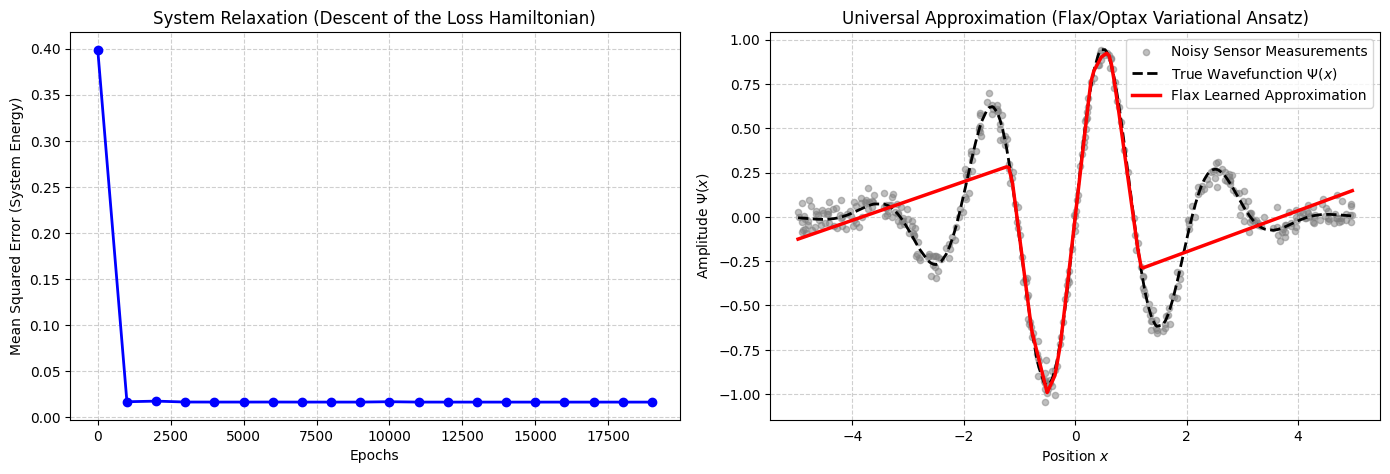

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Thermodynamic Energy Decay (Loss)  <-- was right
axes[0].plot(epochs_sampled, loss_history, 'b-', lw=2, marker='o')
axes[0].set_title("System Relaxation (Descent of the Loss Hamiltonian)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Mean Squared Error (System Energy)")
axes[0].grid(True, linestyle='--', alpha=0.6)

# RIGHT: The Function Approximation       <-- was left
axes[1].scatter(X_raw, Y_train_noisy, color='gray', alpha=0.5, s=20,
                label='Noisy Sensor Measurements')
axes[1].plot(X_raw, Y_true, 'k--', lw=2, label=r'True Wavefunction $\Psi(x)$')
axes[1].plot(X_raw, Y_pred, 'r-', lw=2.5, label='Flax Learned Approximation')
axes[1].set_title("Universal Approximation (Flax/Optax Variational Ansatz)")
axes[1].set_xlabel(r"Position $x$")
axes[1].set_ylabel(r"Amplitude $\Psi(x)$")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


### Conclusion

By replacing the imperative NumPy implementation with the **Flax + Optax** ecosystem, we achieved the exact same mathematical result with several immense advantages:
1. **Zero Manual Calculus:** `jax.value_and_grad` generated exact reverse-mode derivatives instantly. If we wish to add more layers, change to Swish activations, or add physics-informed residual penalty terms (PINNs) to the loss function, the analytical gradients resolve automatically without any manual code refactoring.
2. **XLA Acceleration:** The entire `train_step` was compiled to a single GPU kernel, drastically reducing memory bandwidth bottlenecks.
3. **Functional Safety:** Our architecture is strictly functionally pure. Weight updates are immutable transformations managed by `TrainState`, completely eliminating race conditions and side effects when migrating to multi-GPU clusters via `jax.pmap`.